# **Predicting Credit Default Risk from Application and Transaction Records**

*by Lin Zhu 2025-11*

## Business Context:

Credit score cards are a common risk control method in the financial industry.  
It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings.  
The bank is able to decide whether to issue a credit card to the applicant.

---

Credit score cards are a common risk control method in the financial industry. It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings. The bank is able to decide whether to issue a credit card to the applicant. Credit scores can objectively quantify the magnitude of risk.

Generally speaking, credit score cards are based on historical data. Once encountering large economic fluctuations. Past models may lose their original predictive power. Logistic model is a common method for credit scoring. Because Logistic is suitable for binary classification tasks and can calculate the coefficients of each feature. In order to facilitate understanding and operation, the score card will multiply the logistic regression coefficient by a certain value (such as 100) and round it.

At present, with the development of machine learning algorithms. More predictive methods such as Boosting, Random Forest, and Support Vector Machines have been introduced into credit card scoring. However, these methods often do not have good transparency. It may be difficult to provide customers and regulators with a reason for rejection or acceptance.


In [1]:
# Core
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)

import lightgbm as lgb


In [2]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()


applications = pd.read_csv(io.BytesIO(uploaded['application_record.csv']))
record = pd.read_csv(io.BytesIO(uploaded['credit_record.csv']))

print("applications shape:", applications.shape)
print("record shape:", record.shape)

applications.head()


Saving application_record.csv to application_record.csv
Saving credit_record.csv to credit_record.csv
applications shape: (406230, 18)
record shape: (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


In [3]:
# Basic cleaning
applications.columns = applications.columns.str.strip().str.lower()
record.columns       = record.columns.str.strip().str.lower()

# Drop duplicate applicants (keep first record)
applications = applications.drop_duplicates(subset=applications.columns[1:], keep="first")

# Quick missing rate
missing = (applications.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))
display(missing[missing.missing_rate>0].head(20))


,missing_rate
occupation_type,0.305876
name_family_status,0.000012
flag_email,0.000012
cnt_fam_members,0.000012
flag_phone,0.000012
name_housing_type,0.000012
days_employed,0.000012
flag_mobil,0.000012
days_birth,0.000012
flag_work_phone,0.000012


In [4]:
# Build target from credit record:
# status: 'C' (paid), 'X' (no loan), '0'..'5' (days past due buckets)
tmp = record.copy()
tmp["target"] = tmp["status"].replace({"X":0, "C":0}).astype(int)
tmp.loc[tmp["target"]>=1, "target"] = 1

target_df = (tmp.groupby("id")["target"].max()
               .rename("target")
               .reset_index())

# Merge applicant profiles + target
df = applications.merge(target_df, on="id", how="inner")

print("Merged dataset:", df.shape)
print("Target rate:", df["target"].mean().round(4))
df["target"].value_counts().to_frame("count")


Merged dataset: (9592, 19)
Target rate: 0.1216


,count
target,
0,8426
1,1166


In [5]:
# Feature engineering
# 1) Account length: how long the credit account has existed (months)
start_df = (record.groupby("id")["months_balance"].min()
                 .rename("account_length")
                 .reset_index())
start_df["account_length"] = -start_df["account_length"]  # make positive
df = df.merge(start_df, on="id", how="left")

# 2) Age in years (days_birth is negative days)
df["age_years"] = (-df["days_birth"] / 365.25).round(1)

# 3) Unemployed indicator (days_employed can be positive for special values)
df["unemployed"] = (df["days_employed"] >= 0).astype("int8")

# 4) Work-age ratio (years employed / age), clipped to [0,1]
years_employed = (-df["days_employed"] / 365.25).clip(lower=0)
df["work_age_ratio"] = (years_employed / df["age_years"]).clip(0, 1)

# 5) Simple semantic binaries from categorical fields (normalize strings first)
def _norm(s: pd.Series):
    return (s.astype("string")
              .str.strip()
              .str.lower()
              .str.replace(r"\s+", " ", regex=True))

df["name_income_type_"]    = _norm(df["name_income_type"])
df["name_education_type_"] = _norm(df["name_education_type"])
df["name_housing_type_"]   = _norm(df["name_housing_type"])

df["income_employed"] = df["name_income_type_"].isin({"working","commercial associate","state servant"}).astype("int8")
df["edu_higher_plus"] = df["name_education_type_"].isin({"higher education","academic degree"}).astype("int8")
df["housing_owned"]   = df["name_housing_type_"].isin({"house / apartment","co-op apartment"}).astype("int8")

# Drop helper cols
df = df.drop(columns=["name_income_type_","name_education_type_","name_housing_type_"])

display(df[["account_length","age_years","unemployed","work_age_ratio","income_employed","edu_higher_plus","housing_owned","target"]].head())


,account_length,age_years,unemployed,work_age_ratio,income_employed,edu_higher_plus,housing_owned,target
0,15,32.9,0,0.377973,1,1,0,1
1,29,58.8,0,0.052801,1,0,1,0
2,4,52.3,0,0.159717,1,0,1,0
3,20,61.5,1,0.000000,0,1,1,0
4,5,46.2,0,0.045572,1,1,1,0


In [6]:
# Model matrix
y = df["target"].astype(int)

# Choose features (drop ID + raw date-like features; keep engineered + original usable)
drop_cols = {"id","target"}
X = df.drop(columns=list(drop_cols))

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (7673, 53) X_test: (1919, 53)


In [7]:
# LightGBM + RandomizedSearchCV (optimize AUC)
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best = search.best_estimator_
print("Best params:", search.best_params_)

y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"]))

metrics = {
    "accuracy":  accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall":    recall_score(y_test, y_pred),
    "f1":        f1_score(y_test, y_pred),
    "auc":       roc_auc_score(y_test, y_prob),
}
pd.Series(metrics).round(4)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 933, number of negative: 6740
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1253
[LightGBM] [Info] Number of data points in the train set: 7673, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121595 -> initscore=-1.977410
[LightGBM] [Info] Start training from score -1.977410
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0
accuracy,0.8786
precision,0.0000
recall,0.0000
f1,0.0000
auc,0.5868


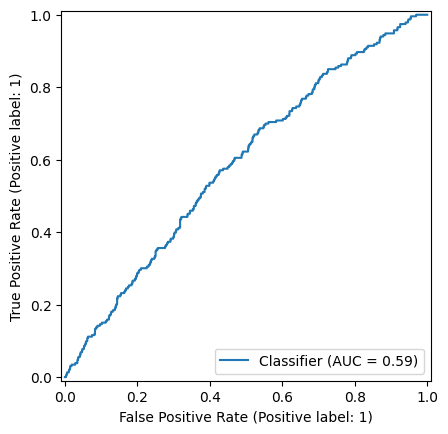

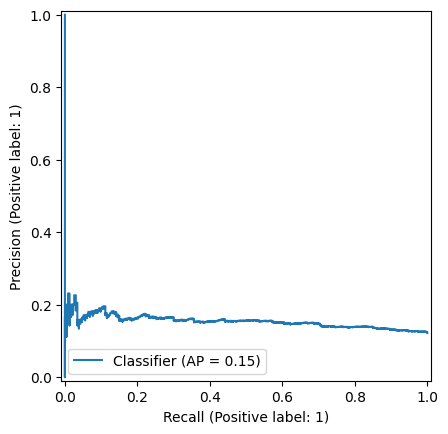

In [8]:
# ROC / PR curves
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.show()


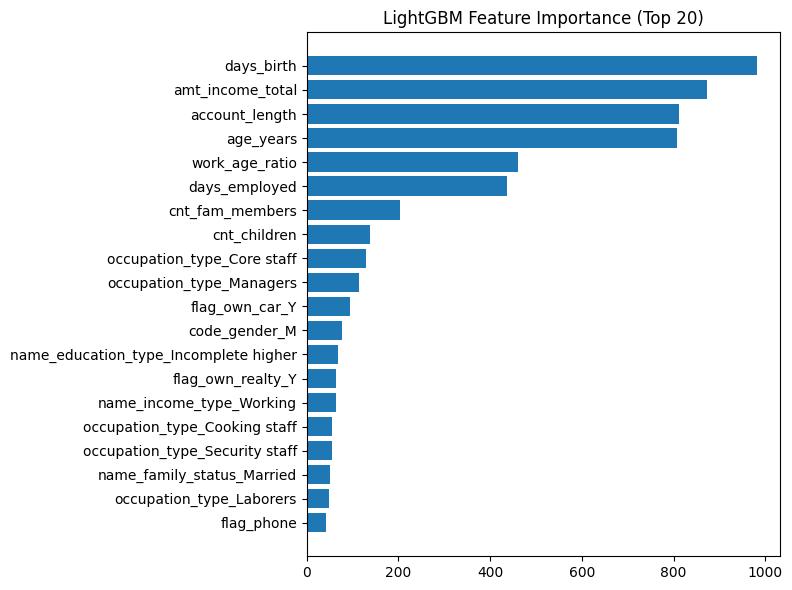

,0
days_birth,983
amt_income_total,873
account_length,812
age_years,808
work_age_ratio,460
days_employed,437
cnt_fam_members,203
cnt_children,137
occupation_type_Core staff,130
occupation_type_Managers,113


In [9]:
# Feature importance (top 20)
imp = (pd.Series(best.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False)
         .head(20)[::-1])

plt.figure(figsize=(8,6))
plt.barh(imp.index.astype(str), imp.values)
plt.title("LightGBM Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

imp.sort_values(ascending=False).head(10)


In [10]:
# Simple risk profiling: default rate by feature bins for top features
top_feats = imp.sort_values(ascending=False).head(5).index.tolist()

for f in top_feats:
    s = X_test[f]
    tmp = pd.DataFrame({"x": s, "y": y_test.values})
    if pd.api.types.is_numeric_dtype(tmp["x"]):
        tmp["bin"] = pd.qcut(tmp["x"], 5, duplicates="drop")
        grp = tmp.groupby("bin", observed=True)["y"].mean()
        print(f"\nDefault rate by {f}:")
        display(grp.to_frame("default_rate"))



Default rate by days_birth:


,default_rate
bin,
"(-24970.001, -20125.0]",0.093750
"(-20125.0, -16913.6]",0.119792
"(-16913.6, -14210.2]",0.096606
"(-14210.2, -11736.0]",0.132124
"(-11736.0, -7757.0]",0.164921



Default rate by amt_income_total:


,default_rate
bin,
"(26999.999, 112500.0]",0.118012
"(112500.0, 135000.0]",0.127036
"(135000.0, 180000.0]",0.127962
"(180000.0, 234000.0]",0.126543
"(234000.0, 810000.0]",0.109661



Default rate by account_length:


,default_rate
bin,
"(-0.001, 11.0]",0.090226
"(11.0, 21.0]",0.095960
"(21.0, 33.0]",0.163488
"(33.0, 45.0]",0.119171
"(45.0, 60.0]",0.142857



Default rate by age_years:


,default_rate
bin,
"(21.198999999999998, 32.1]",0.166234
"(32.1, 38.9]",0.132124
"(38.9, 46.3]",0.093750
"(46.3, 55.1]",0.123037
"(55.1, 68.4]",0.091623



Default rate by work_age_ratio:


,default_rate
bin,
"(-0.001, 0.0134]",0.093750
"(0.0134, 0.0699]",0.117188
"(0.0699, 0.136]",0.177546
"(0.136, 0.24]",0.132812
"(0.24, 0.686]",0.085938


### **Limitations & Next Steps**

- Temporal validation could be improved by using time-based splits.
- Model explainability (e.g., SHAP) can be added for regulatory interpretability.
- Cost-sensitive thresholds can be tuned based on business loss functions.
